In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.3.0


# SAR Survey of a Parking Lot

An end-to-end `sim_radar` ray-tracing demo: a small parking lot with six real vehicle meshes (two sedans, two pickups, a box truck, a tanker — tens to hundreds of thousands of facets each) on a flat ground plane, illuminated by a C-band LFM chirp from a side-looking stripmap platform. Downstream processing — range compression and Back-Projection (BPA) — is standard SAR; the interesting part is the physical realism `sim_radar` feeds it: real CAD geometry, mixed materials, and a multi-segment flight built by chaining `sim_radar` calls.

Because the scene has real 3-D structure, the focused image shows **relief displacement (layover)** — not scripted, but an emergent consequence of ray-tracing genuine geometry against BPA's flat-earth reference: every vehicle above `z_ref` returns energy at a shorter range than the ground around it.

**Showcased:** ray tracing over real multi-mesh scenes · mixed target materials (PEC vehicles, dielectric ground) · independently configurable az/el antenna patterns · long-duration flight synthesis via chained `sim_radar` calls · tunable ray density · a full LFM → raw data → range compression → Back-Projection SAR pipeline.

## Setup

In [2]:
import time
import numpy as np
import scipy
from scipy import constants
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
import pymeshlab
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

## Scene Setup: A Parking Lot

`RadarSimPy` ray-traces targets directly from STL meshes — no primitives or parametric approximations. The scene has six vehicles from four real models in `models/vehicles/`: two sedans (`tesla_model_s.stl`), two pickups (`ford_raptor.stl`), a box truck (`scania_truck.stl`), and a tanker (`gasoline_tanker.stl`), parked over a flat 60 m × 60 m ground plane (`surface_60x60.stl`). Later "ground truth" comparisons approximate each vehicle as a flat-topped box using its true bounding-box dimensions.

6 vehicles parked on a flat 60 m x 60 m ground plane:
  gasoline_tanker     : x=+0.0 m, y=+15.0 m, yaw=+45 deg  (21.0 x 3.6 x 4.3 m)
  scania_truck        : x=-22.0 m, y=-15.0 m, yaw=+30 deg  (13.2 x 3.0 x 3.7 m)
  tesla_model_s #1    : x=+14.0 m, y=-14.0 m, yaw=+0 deg  (4.9 x 2.2 x 1.5 m)
  tesla_model_s #2    : x=-16.0 m, y=+20.0 m, yaw=+0 deg  (4.9 x 2.2 x 1.5 m)
  ford_raptor #1      : x=+22.0 m, y=+10.0 m, yaw=+0 deg  (5.2 x 2.2 x 1.8 m)
  ford_raptor #2      : x=+6.0 m, y=-21.0 m, yaw=+0 deg  (5.2 x 2.2 x 1.8 m)


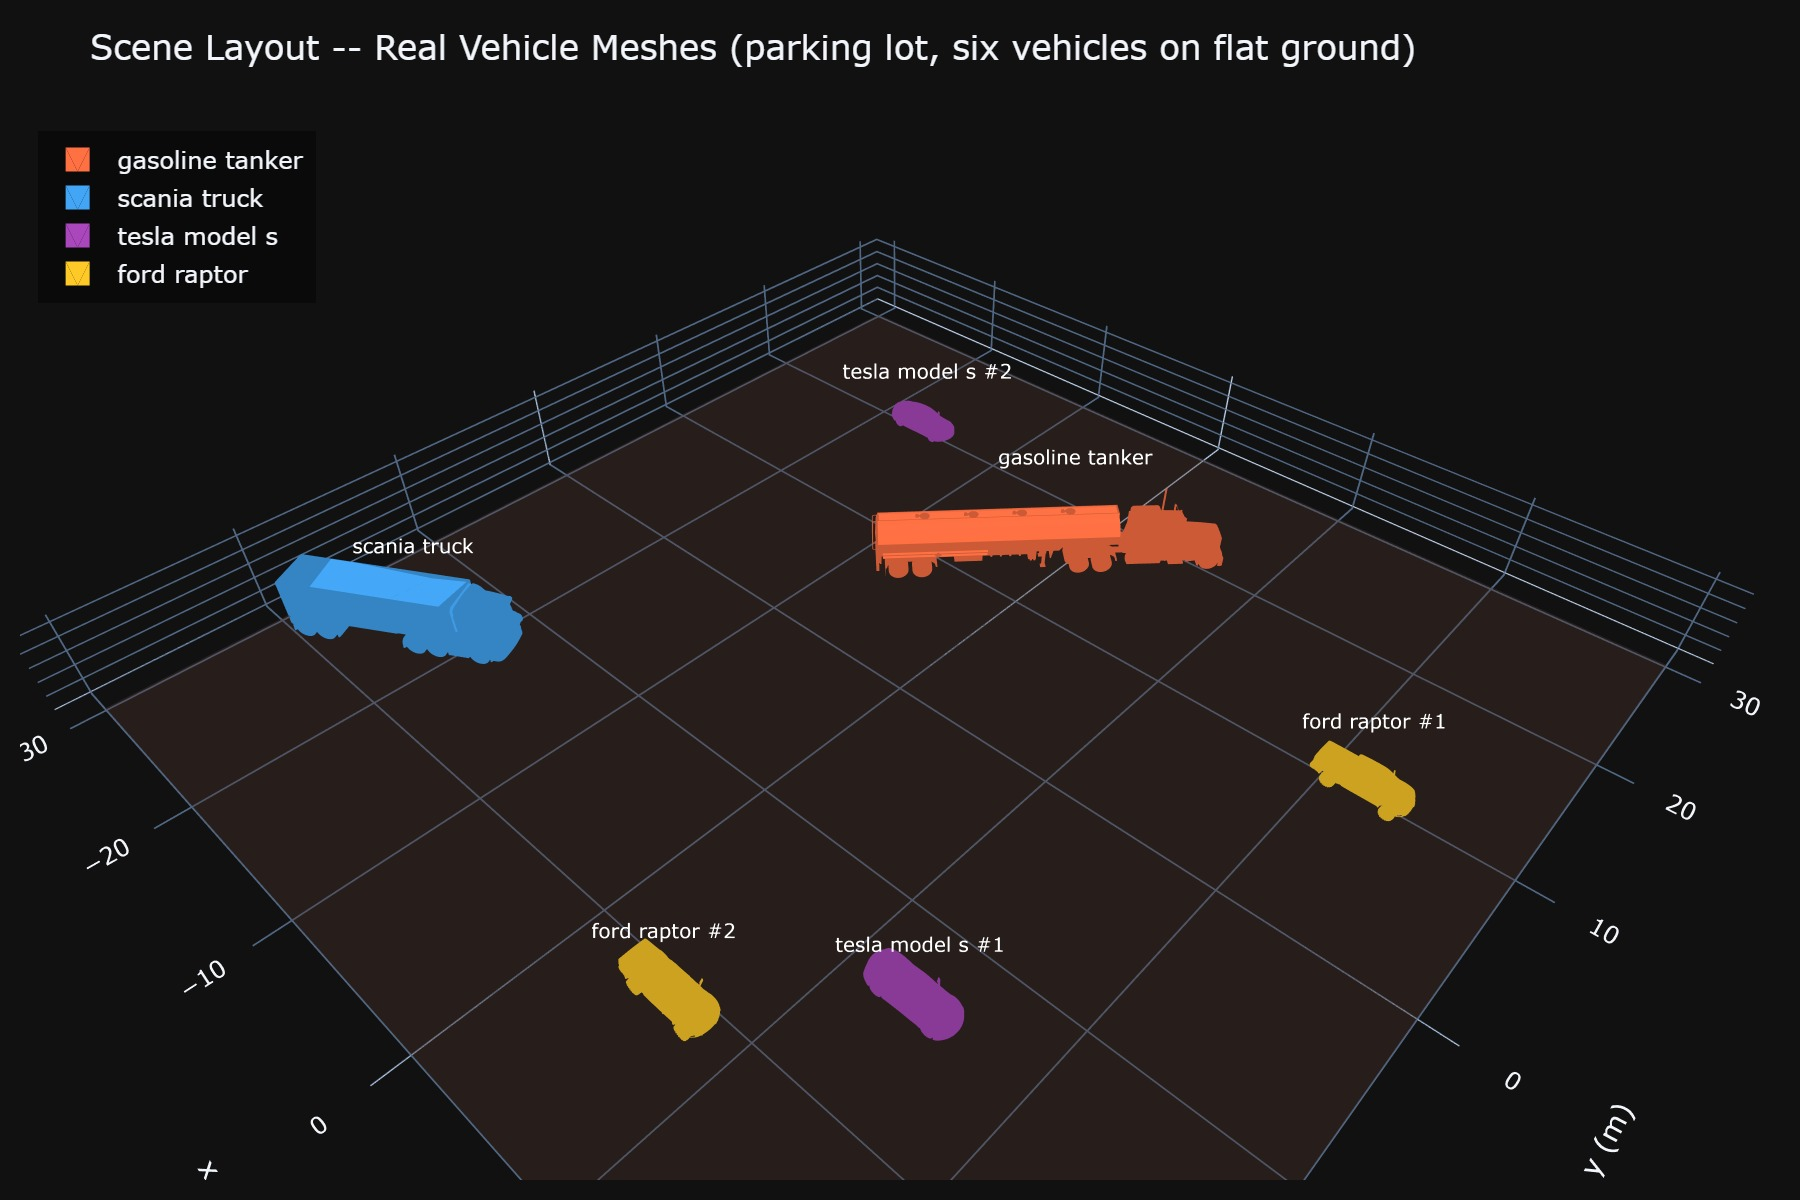

In [3]:
# Vehicle bounding-box dims (L, W, H) -- used for the analytic ground-truth height field,
# approximating each real STL mesh as a flat-topped box.
VEHICLE_DIMS = {
    "gasoline_tanker": (
        21.0,
        3.6,
        4.3,
    ),  # tanker semi-trailer -- tallest, longest vehicle here
    "scania_truck": (13.2, 3.0, 3.7),  # box truck
    "tesla_model_s": (4.9, 2.2, 1.5),  # sedan
    "ford_raptor": (5.2, 2.2, 1.8),  # pickup truck
}

# Scene layout: (x, y, yaw_deg) per vehicle, yaw = CCW rotation about its own centre.
# Yaw was individually tuned by sweeping ray-traced RCS beforehand -- these PEC shapes
# are angle-sensitive; tanker/box truck return strongly at yaw=0 (double bounce), the
# sedan/pickup need a tuned non-zero yaw to register at all.
vehicles = [
    {"name": "gasoline_tanker", "x": 0.0, "y": 15.0, "yaw": 45.0},
    {"name": "scania_truck", "x": -22.0, "y": -15.0, "yaw": 30.0},
    {"name": "tesla_model_s", "x": 14.0, "y": -14.0, "yaw": 0.0},
    {"name": "tesla_model_s", "x": -16.0, "y": 20.0, "yaw": 0.0},
    {"name": "ford_raptor", "x": 22.0, "y": 10.0, "yaw": 0.0},
    {"name": "ford_raptor", "x": 6.0, "y": -21.0, "yaw": 0.0},
]

print(f"{len(vehicles)} vehicles parked on a flat 60 m x 60 m ground plane:")
name_totals = {}
for v in vehicles:
    name_totals[v["name"]] = name_totals.get(v["name"], 0) + 1
seen = {}
for v in vehicles:
    seen[v["name"]] = seen.get(v["name"], 0) + 1
    label = (
        f"{v['name']} #{seen[v['name']]}" if name_totals[v["name"]] > 1 else v["name"]
    )
    L, W, H = VEHICLE_DIMS[v["name"]]
    print(
        f"  {label:20s}: x={v['x']:+.1f} m, y={v['y']:+.1f} m, yaw={v['yaw']:+.0f} deg  "
        f"({L:.1f} x {W:.1f} x {H:.1f} m)"
    )


def scene_height(x, y):
    """Approximate true-height field: each vehicle as a flat-topped box at its true bounding-box size."""
    z = np.zeros_like(np.asarray(x, dtype=float))
    for v in vehicles:
        L, W, H = VEHICLE_DIMS[v["name"]]
        theta = np.radians(v["yaw"])
        dx_world = x - v["x"]
        dy_world = y - v["y"]
        # Rotate the query point into the vehicle's own (unrotated) local frame.
        local_x = np.cos(theta) * dx_world + np.sin(theta) * dy_world
        local_y = -np.sin(theta) * dx_world + np.cos(theta) * dy_world
        within = (np.abs(local_x) <= L / 2) & (np.abs(local_y) <= W / 2)
        z = np.where(within, np.maximum(z, H), z)
    return z


# Preview layout with real STL geometry (colored by vehicle type). World-space vertices
# are cached in `vehicle_mesh_cache` and reused later so meshes load from disk once.
VEHICLE_COLORS = {
    "gasoline_tanker": "#FF7043",  # deep orange
    "scania_truck": "#42A5F5",  # blue
    "tesla_model_s": "#AB47BC",  # purple
    "ford_raptor": "#FFCA28",  # amber
}

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=[-30, 30, 30, -30],
        y=[-30, -30, 30, 30],
        z=[0, 0, 0, 0],
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        color="#4E342E",
        opacity=0.35,
        name="Ground plane",
        showscale=False,
        showlegend=False,
    )
)

vehicle_mesh_cache = []
seen_labels = {}
legend_shown = set()
for v in vehicles:
    ms_v = pymeshlab.MeshSet()
    ms_v.load_new_mesh(f"../models/vehicles/{v['name']}.stl")
    vm = ms_v.current_mesh()
    verts_v = np.array(vm.vertex_matrix())
    faces_v = np.array(vm.face_matrix())

    theta = np.radians(v["yaw"])
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    xy_rot = verts_v[:, :2] @ rot.T
    verts_world = np.column_stack([xy_rot, verts_v[:, 2]]) + np.array(
        [v["x"], v["y"], 0.0]
    )
    vehicle_mesh_cache.append(
        {"name": v["name"], "verts": verts_world, "faces": faces_v}
    )

    fig.add_trace(
        go.Mesh3d(
            x=verts_world[:, 0],
            y=verts_world[:, 1],
            z=verts_world[:, 2],
            i=faces_v[:, 0],
            j=faces_v[:, 1],
            k=faces_v[:, 2],
            color=VEHICLE_COLORS[v["name"]],
            flatshading=True,
            name=v["name"].replace("_", " "),
            showlegend=v["name"] not in legend_shown,
        )
    )
    legend_shown.add(v["name"])

    seen_labels[v["name"]] = seen_labels.get(v["name"], 0) + 1
    label = (
        f"{v['name']} #{seen_labels[v['name']]}"
        if name_totals[v["name"]] > 1
        else v["name"]
    )
    _, _, H = VEHICLE_DIMS[v["name"]]
    fig.add_trace(
        go.Scatter3d(
            x=[v["x"]],
            y=[v["y"]],
            z=[H + 1.0],
            mode="text",
            text=[label.replace("_", " ")],
            textfont=dict(color="white", size=10),
            showlegend=False,
        )
    )

fig.update_layout(
    title="Scene Layout -- Real Vehicle Meshes (parking lot, six vehicles on flat ground)",
    scene=dict(
        xaxis_title="x (m)",
        yaxis_title="y (m)",
        zaxis_title="Height (m)",
        aspectmode="data",
        camera=dict(eye=dict(x=1.2, y=-1.3, z=1.6)),
    ),
    template="plotly_dark",
    width=900,
    height=600,
    margin=dict(l=10, r=10, b=10, t=60),
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(0,0,0,0.4)"),
)
show(fig)

### Imaging Window

The imaging swath is centred on the parking lot, with enough margin on all sides to keep every vehicle comfortably inside the focused image.

| Parameter | Value |
|---|---|
| Azimuth (along-track) reference `cx` | 0.0 m |
| Cross-track survey swath `y` | -25.0 – 25.0 m |
| Scene height range | 0 (ground, exact) – 4.3 m (tanker roof) |

In [4]:
cx = 0.0
y0, y1 = -25.0, 25.0

print(f"Cross-track swath: y = {y0:.1f} to {y1:.1f} m")
for v in vehicles:
    print(
        f"  {v['name']:18s} (x={v['x']:+.1f}, y={v['y']:+.1f}, yaw={v['yaw']:+.0f} deg): "
        f"inside swath = {y0 <= v['y'] <= y1}"
    )

Cross-track swath: y = -25.0 to 25.0 m
  gasoline_tanker    (x=+0.0, y=+15.0, yaw=+45 deg): inside swath = True
  scania_truck       (x=-22.0, y=-15.0, yaw=+30 deg): inside swath = True
  tesla_model_s      (x=+14.0, y=-14.0, yaw=+0 deg): inside swath = True
  tesla_model_s      (x=-16.0, y=+20.0, yaw=+0 deg): inside swath = True
  ford_raptor        (x=+22.0, y=+10.0, yaw=+0 deg): inside swath = True
  ford_raptor        (x=+6.0, y=-21.0, yaw=+0 deg): inside swath = True


### Waveform, Flight Geometry & Sampling Parameters

A **C-band LFM chirp** (`fc` = 4 GHz, `B` = 800 MHz → ΔR = 0.187 m, a 20% fractional bandwidth) with a short **2 μs pulse** — slant ranges are only ~160-210 m, so `fs` stays near 1.3 GHz.

A genuine **3-D side-looking stripmap** geometry: the platform flies at altitude with lateral standoff from the swath, so every pixel has both cross-track and vertical offset.

**Notes:**
- Depression angle (≈14-18°) controls return strength, not just layover — the box truck/tanker rely on a wall-ground double bounce; the sedan/pickup are fainter and need an RCS-tuned yaw.
- The ground is exactly flat, so `z_ref` = 0 m is exact — all layover in the final image comes from the vehicles above it.
- **Sliding-aperture stripmap focusing**: each pixel is focused only from pulses inside the antenna's real-beam footprint, so PRF just needs `PRF > 2v/Dₐ` and pulse count grows linearly (not quadratically) with swath length. Azimuth resolution is fixed at `Dₐ/2` (0.375 m) — a smaller antenna gives finer resolution.
- PRF is oversampled 4x Nyquist for better speckle averaging and lower sidelobes.
- `sim_radar` caps motion updates at ≈5 s and pulses per call, so this notebook chains `n_segments` calls, each with its own `radar.set_motion(...)`, concatenating range-compressed results before Back-Projection.

In [5]:
c = constants.c  # Speed of light (m/s)

# Carrier / LFM waveform
fc = 4e9  # Carrier frequency (Hz) - C-band
lam = c / fc  # Wavelength (m)
bw = 800e6  # LFM sweep bandwidth (Hz)  ->  dR = c/(2B) = 0.187 m  (20% fractional BW)
tpd = 2e-6  # Chirp (pulse) duration (s) - short; ranges here are only ~160-210 m
tx_power_dbm = 40  # Transmit power (dBm)

# Platform / flight-line geometry
Da = 0.75  # Real antenna azimuth dimension (m) - smaller aperture -> finer stripmap az resolution
v_platform = 5.0  # Along-track velocity (m/s) - slow-flying survey UAS
y_fly = -180.0  # Flight line cross-track position (m) - standoff from the swath
z_fly = 50.0  # Flight altitude (m) - a slow, low flyover, not a mapping mission
z_ref = 0.0  # Flat-earth reference elevation assumed by Back-Projection (m) - EXACT ground truth here

ymid = (y0 + y1) / 2
dep_center = np.degrees(np.arctan2(z_fly - z_ref, ymid - y_fly))
dep_near = np.degrees(np.arctan2(z_fly - z_ref, y0 - y_fly))
dep_far = np.degrees(np.arctan2(z_fly - z_ref, y1 - y_fly))
R_near = np.hypot(y0 - y_fly, z_fly - z_ref)
R_far = np.hypot(y1 - y_fly, z_fly - z_ref)
R_mid = (R_near + R_far) / 2

# Azimuth sampling: sliding-window stripmap needs only the LOCAL Nyquist criterion
# (PRF > 2v/Da), independent of flight length. Resolution is fixed at Da/2 regardless
# of PRF; oversampling just adds more independent looks per pixel (lower speckle/sidelobes).
prf_margin = 4.0  # oversampling factor above the strict Nyquist limit
prf = prf_margin * 2 * v_platform / Da

# Per-call duration is capped: this eval build of sim_radar silently stops updating
# platform motion past ~5.0 s of simulated time. Cap each call below that and chain
# several calls (below) to reach a longer total flight.
max_duration_s = 4.0  # safety margin below the ~5.0 s observed failure point
pulse_cap = 1650  # separate, independent licensed ceiling on pulses-per-call
num_pulses = min(pulse_cap, int(prf * max_duration_s))  # pulses PER segment/call
prp = 1 / prf  # Pulse repetition period (s)
synthetic_aperture = v_platform * num_pulses / prf  # flight length PER segment (m)
actual_duration_s = num_pulses / prf

# Chain several calls end-to-end for a longer total flight
n_segments = 3
total_flight_length = n_segments * synthetic_aperture

# Real-beam footprint: the ground length illuminated by the antenna at any instant.
# Each pixel is focused only from pulses while it sits inside this footprint.
footprint_length = R_mid * lam / Da
az_res_stripmap = (
    Da / 2
)  # real-aperture-limited azimuth resolution (fixed, not aperture-dependent)
pulses_per_dwell = (
    prf * footprint_length / v_platform
)  # independent looks contributing to each pixel

# Derived waveform quantities
range_res = c / (2 * bw)
bt_product = bw * tpd  # Time-bandwidth product
mf_gain_db = 10 * np.log10(bt_product)  # Matched-filter / pulse-compression gain

# Sample rate: must satisfy fs > 4*R_max*B/(c*tau) to avoid beat-frequency aliasing
fs_min = 4 * (R_far + 15) * bw / (c * tpd)
fs = 1300e6  # Chosen with margin above fs_min
pulse_samples = int(
    tpd * fs
)  # Fast-time samples per pulse (dechirped beat-tone record)

print(f"fc={fc/1e9:.0f} GHz  B={bw/1e6:.0f} MHz  tau={tpd*1e6:.1f} us")
print(f"dR={range_res:.3f} m   B*tau={bt_product:.0f}   MF gain={mf_gain_db:.1f} dB")
print(
    f"fs_min={fs_min/1e6:.1f} MHz  ->  fs={fs/1e6:.0f} MHz  ({pulse_samples} samples/pulse)"
)
print(
    f"Flight altitude z={z_fly:.0f} m, standoff y_fly={y_fly:.0f} m, flat-earth reference z_ref={z_ref:.0f} m"
)
print(
    f"Depression angle: near={dep_near:.1f} deg  centre={dep_center:.1f} deg  far={dep_far:.1f} deg"
)
print(f"Slant range: near={R_near:.1f} m  far={R_far:.1f} m  mid={R_mid:.1f} m")
print(
    f"PRF={prf:.2f} Hz ({prf_margin:.1f}x Nyquist)  ->  num_pulses/segment={num_pulses}  "
    f"(duration-capped: {actual_duration_s:.2f} s vs {max_duration_s:.1f} s limit; pulse cap was {pulse_cap})"
)
print(f"Per-segment flight length: {synthetic_aperture:.1f} m")
print(
    f"Chaining {n_segments} segments -> total flight length: {total_flight_length:.1f} m "
    f"({n_segments * num_pulses} pulses total)"
)
print(
    f"Real-beam footprint (per-pixel dwell): {footprint_length:.2f} m  ->  daz(stripmap) = {az_res_stripmap:.3f} m "
    f"({pulses_per_dwell:.0f} pulses illuminate each pixel)"
)

fc=4 GHz  B=800 MHz  tau=2.0 us
dR=0.187 m   B*tau=1600   MF gain=32.0 dB
fs_min=1206.2 MHz  ->  fs=1300 MHz  (2600 samples/pulse)
Flight altitude z=50 m, standoff y_fly=-180 m, flat-earth reference z_ref=0 m
Depression angle: near=17.9 deg  centre=15.5 deg  far=13.7 deg
Slant range: near=162.9 m  far=211.0 m  mid=186.9 m
PRF=53.33 Hz (4.0x Nyquist)  ->  num_pulses/segment=213  (duration-capped: 3.99 s vs 4.0 s limit; pulse cap was 1650)
Per-segment flight length: 20.0 m
Chaining 3 segments -> total flight length: 59.9 m (639 pulses total)
Real-beam footprint (per-pixel dwell): 18.68 m  ->  daz(stripmap) = 0.375 m (199 pulses illuminate each pixel)


### Transmitter, Receiver & Antenna

Each channel carries its own az/el gain pattern, so the antenna is asymmetric, matched to the illumination geometry:
- **Azimuth** is narrow (0.75 m antenna @ 4 GHz → ≈5.7° 3 dB beamwidth), which defines the real-beam footprint each pixel is focused from.
- **Elevation** is wide, staying flat across the swath's ≈13.7-17.9° depression-angle spread.

The receiver samples at `fs` = 1.3 GHz, set to keep the beat frequency unambiguous out to the far swath edge.

In [6]:
# -- Antenna pattern --------------------------------------------------------
antenna_gain = 20  # dBi

# Azimuth: cos^n exponent is DERIVED so the pattern's actual -3 dB half-angle matches
# lam/(2*Da), the beamwidth the real-beam footprint formula assumes.
az_beamwidth_half_rad = lam / (2 * Da)
az_n = -3 / (20 * np.log10(np.cos(az_beamwidth_half_rad)))
az_angle = np.arange(-15, 16, 1)
az_pattern = 20 * az_n * np.log10(np.abs(np.cos(az_angle / 180 * np.pi))) + antenna_gain

# Elevation: wide -- must stay reasonably flat across the swath's depression-angle spread
el_angle = np.arange(-20, 21, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 3) + antenna_gain

tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

# -- LFM chirp waveform: f sweeps [fc-B/2, fc+B/2] over t=[0, tau]; idle for the rest of the PRP
tx = Transmitter(
    f=[fc - bw / 2, fc + bw / 2],
    t=[0, tpd],
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    prp=prp,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Chirp: {(fc-bw/2)/1e9:.4f} -> {(fc+bw/2)/1e9:.4f} GHz over {tpd*1e6:.1f} us")
print(f"  Duty cycle: {tpd/prp*100:.2f}%")
print(
    f"  Azimuth pattern: cos^{az_n:.0f}, actual -3dB half-angle = "
    f"{np.degrees(az_beamwidth_half_rad):.2f} deg"
)

Transmitter configured.
  Chirp: 3.6000 -> 4.4000 GHz over 2.0 us
  Duty cycle: 0.01%
  Azimuth pattern: cos^277, actual -3dB half-angle = 2.86 deg


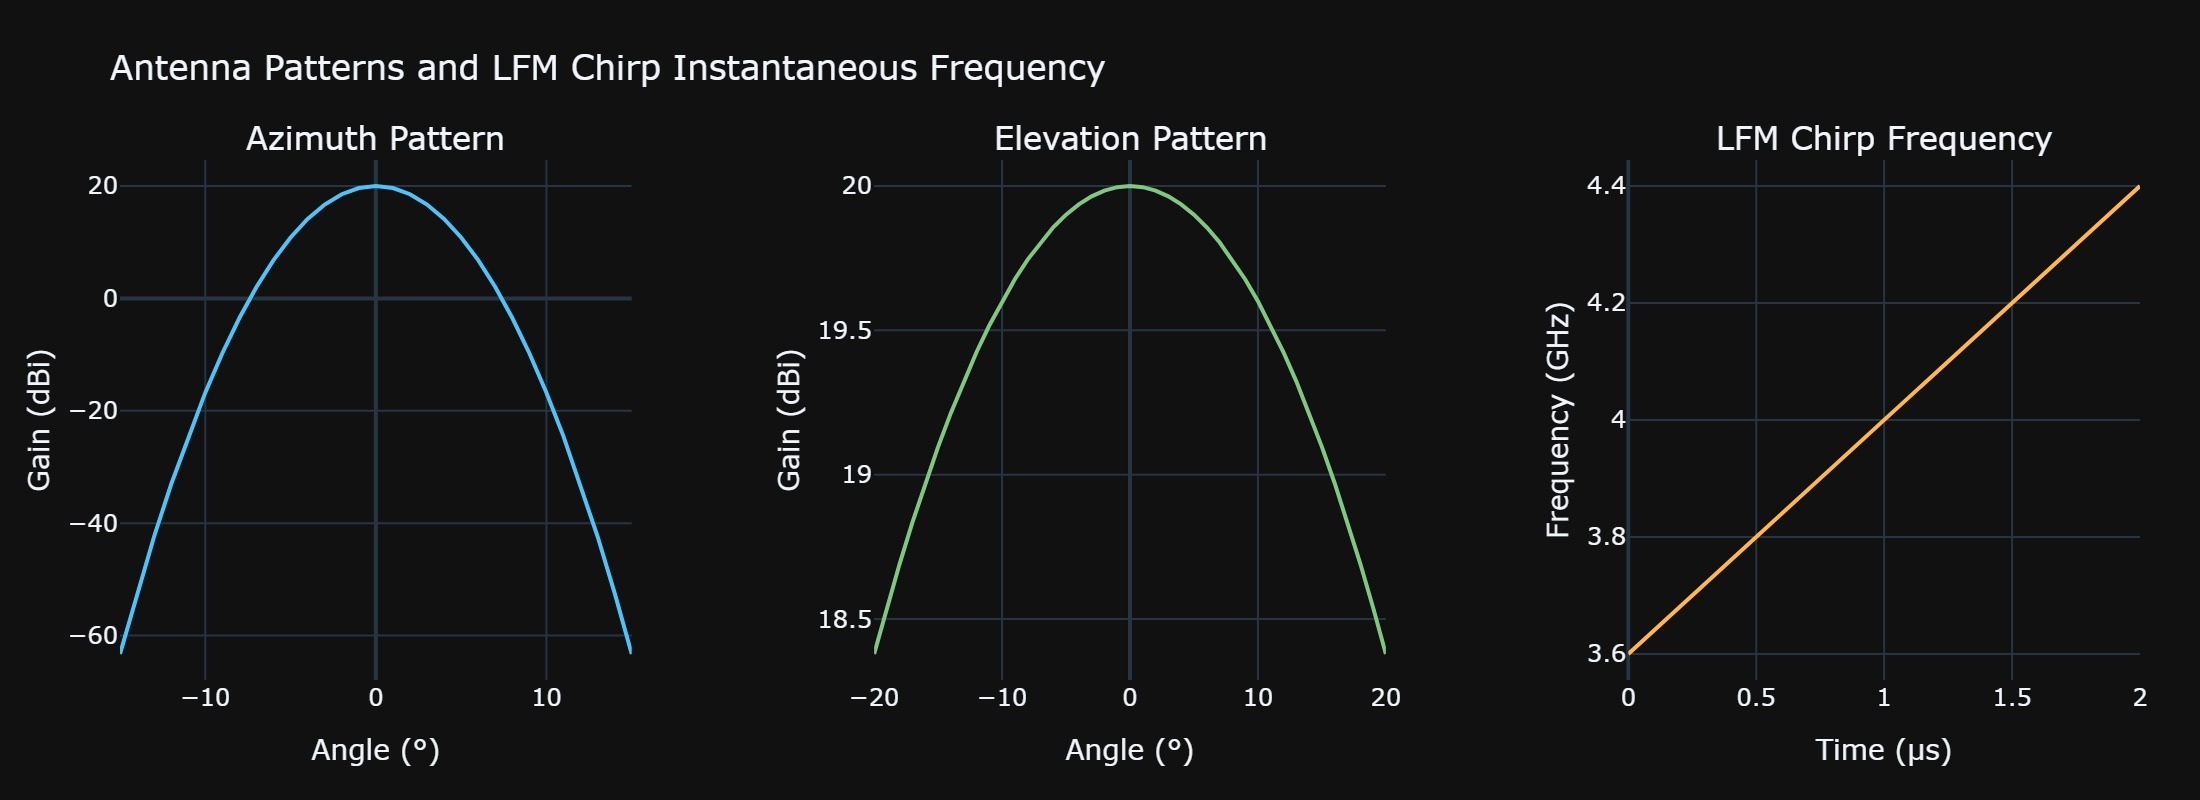

In [7]:
t_chirp = np.linspace(0, tpd, 500)
inst_freq_ghz = (fc + (bw / tpd) * (t_chirp - tpd / 2)) / 1e9  # instantaneous frequency

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "LFM Chirp Frequency"),
    horizontal_spacing=0.12,
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, line=dict(color="#4FC3F7", width=2)),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, line=dict(color="#81C784", width=2)),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=t_chirp * 1e6,
        y=inst_freq_ghz,
        line=dict(color="#FFB74D", width=2),
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", title_standoff=5, row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", title_standoff=5, row=1, col=2)
fig.update_yaxes(title_text="Frequency (GHz)", title_standoff=5, row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and LFM Chirp Instantaneous Frequency",
    template="plotly_dark",
    height=400,
    width=1100,
    showlegend=False,
    margin=dict(l=60, r=30, t=80, b=60),
)
show(fig)

In [8]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,  # NF = 5 dB
    rf_gain=20,  # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate      : {fs/1e6:.0f} MHz")
print(f"  Samples per pulse: {pulse_samples}")

Receiver configured.
  Sample rate      : 1300 MHz
  Samples per pulse: 2600


### Platform Trajectory & Scene

The platform flies straight and level along **+x** at 5 m/s, offset 180 m cross-track (standoff 155-205 m) and 50 m up. That standoff keeps the depression angle shallow, avoiding near-nadir fold-over while keeping the double-bounce return strong. Boresight is yawed 90° (broadside, +y) and pitched down by the ≈15.5° centre depression angle.

The flight is split into `n_segments` back-to-back stretches, each within the duration/pulse cap, continuing from where the previous segment left off:

| Parameter | Value |
|---|---|
| Per-segment flight | ≈20 m, ≈4.0 s, PRF≈53.3 Hz, 213 pulses |
| Chained flight | 3 segments → x ∈ [cx−30, cx+30] m (≈60 m), y=-180 m, z=50 m |
| Depression angle | ≈17.9° (near) → ≈15.5° (centre) → ≈13.7° (far) |
| `z_ref` | 0 m — the scene's actual, exact ground elevation |

The target scene: a flat ground plane plus six vehicles (sedan, pickup, box truck, tanker), each contributing its own return.

In [9]:
# Precompute the full multi-segment flight path (pure geometry) for preview and reuse.
segment_centers = (
    cx - total_flight_length / 2 + synthetic_aperture * (np.arange(n_segments) + 0.5)
)

pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()

platform_x = np.concatenate(
    [seg_center + v_platform * pulse_times for seg_center in segment_centers]
)
num_pulses_total = len(platform_x)

print(
    f"Chaining {n_segments} segments x {num_pulses} pulses = {num_pulses_total} pulses total"
)
print(f"Segment centres (x): {np.array2string(segment_centers, precision=1)}")
print(
    f"Full flight span: x = {platform_x.min():.1f} to {platform_x.max():.1f} m "
    f"({platform_x.max()-platform_x.min():.1f} m)"
)

Chaining 3 segments x 213 pulses = 639 pulses total
Segment centres (x): [-20.   0.  20.]
Full flight span: x = -29.9 to 29.9 m (59.8 m)


In [10]:
radar = Radar(
    transmitter=tx,
    receiver=rx,
)

# Motion is NOT set here -- each segment gets its own radar.set_motion(...) call during
# simulation (below), reusing this same Radar object with a fresh set of positions.

print(
    f"Radar created. {n_segments} segments x {num_pulses} pulses each = {num_pulses_total} pulses total."
)
print(f"  Platform y={y_fly:.0f} m, z={z_fly:.0f} m")
print(
    f"  Boresight: yaw=90 deg (+y broadside), pitch={-dep_center:.1f} deg (elevation tilt)"
)

Radar created. 3 segments x 213 pulses each = 639 pulses total.
  Platform y=-180 m, z=50 m
  Boresight: yaw=90 deg (+y broadside), pitch=-15.5 deg (elevation tilt)


In [11]:
# Targets: ray-traced together in one scene, each with its own mesh/material options.
ground_target = {
    "model": "../models/surface_60x60.stl",  # flat 60 m x 60 m ground plane, centred at origin
    "location": (0, 0, 0),
    "speed": (0, 0, 0),
    "permittivity": 3.2 + 0.1j,  # soil/asphalt-like dielectric
    "skip_diffusion": True,  # large flat reflector -- specular only, keeps runtime down
    "environment": True,  # large surrounding surface -- reduced ray density
}

vehicle_targets = [
    {
        "model": f"../models/vehicles/{v['name']}.stl",
        "location": (v["x"], v["y"], 0),
        "rotation": (v["yaw"], 0, 0),
        "speed": (0, 0, 0),
        # no permittivity override -- defaults to PEC
    }
    for v in vehicles
]

targets = [ground_target] + vehicle_targets

max_h = max(h for _, _, h in VEHICLE_DIMS.values())
print(f"Target: 1 ground plane (60 m x 60 m) + {len(vehicle_targets)} vehicles (PEC)")
print(f"  Illuminated swath: y = {y0:.0f} to {y1:.0f} m (cross-track)")
print(f"  Scene height: 0 m (ground, exact) to {max_h:.1f} m (tallest vehicle)")

Target: 1 ground plane (60 m x 60 m) + 6 vehicles (PEC)
  Illuminated swath: y = -25 to 25 m (cross-track)
  Scene height: 0 m (ground, exact) to 4.3 m (tallest vehicle)


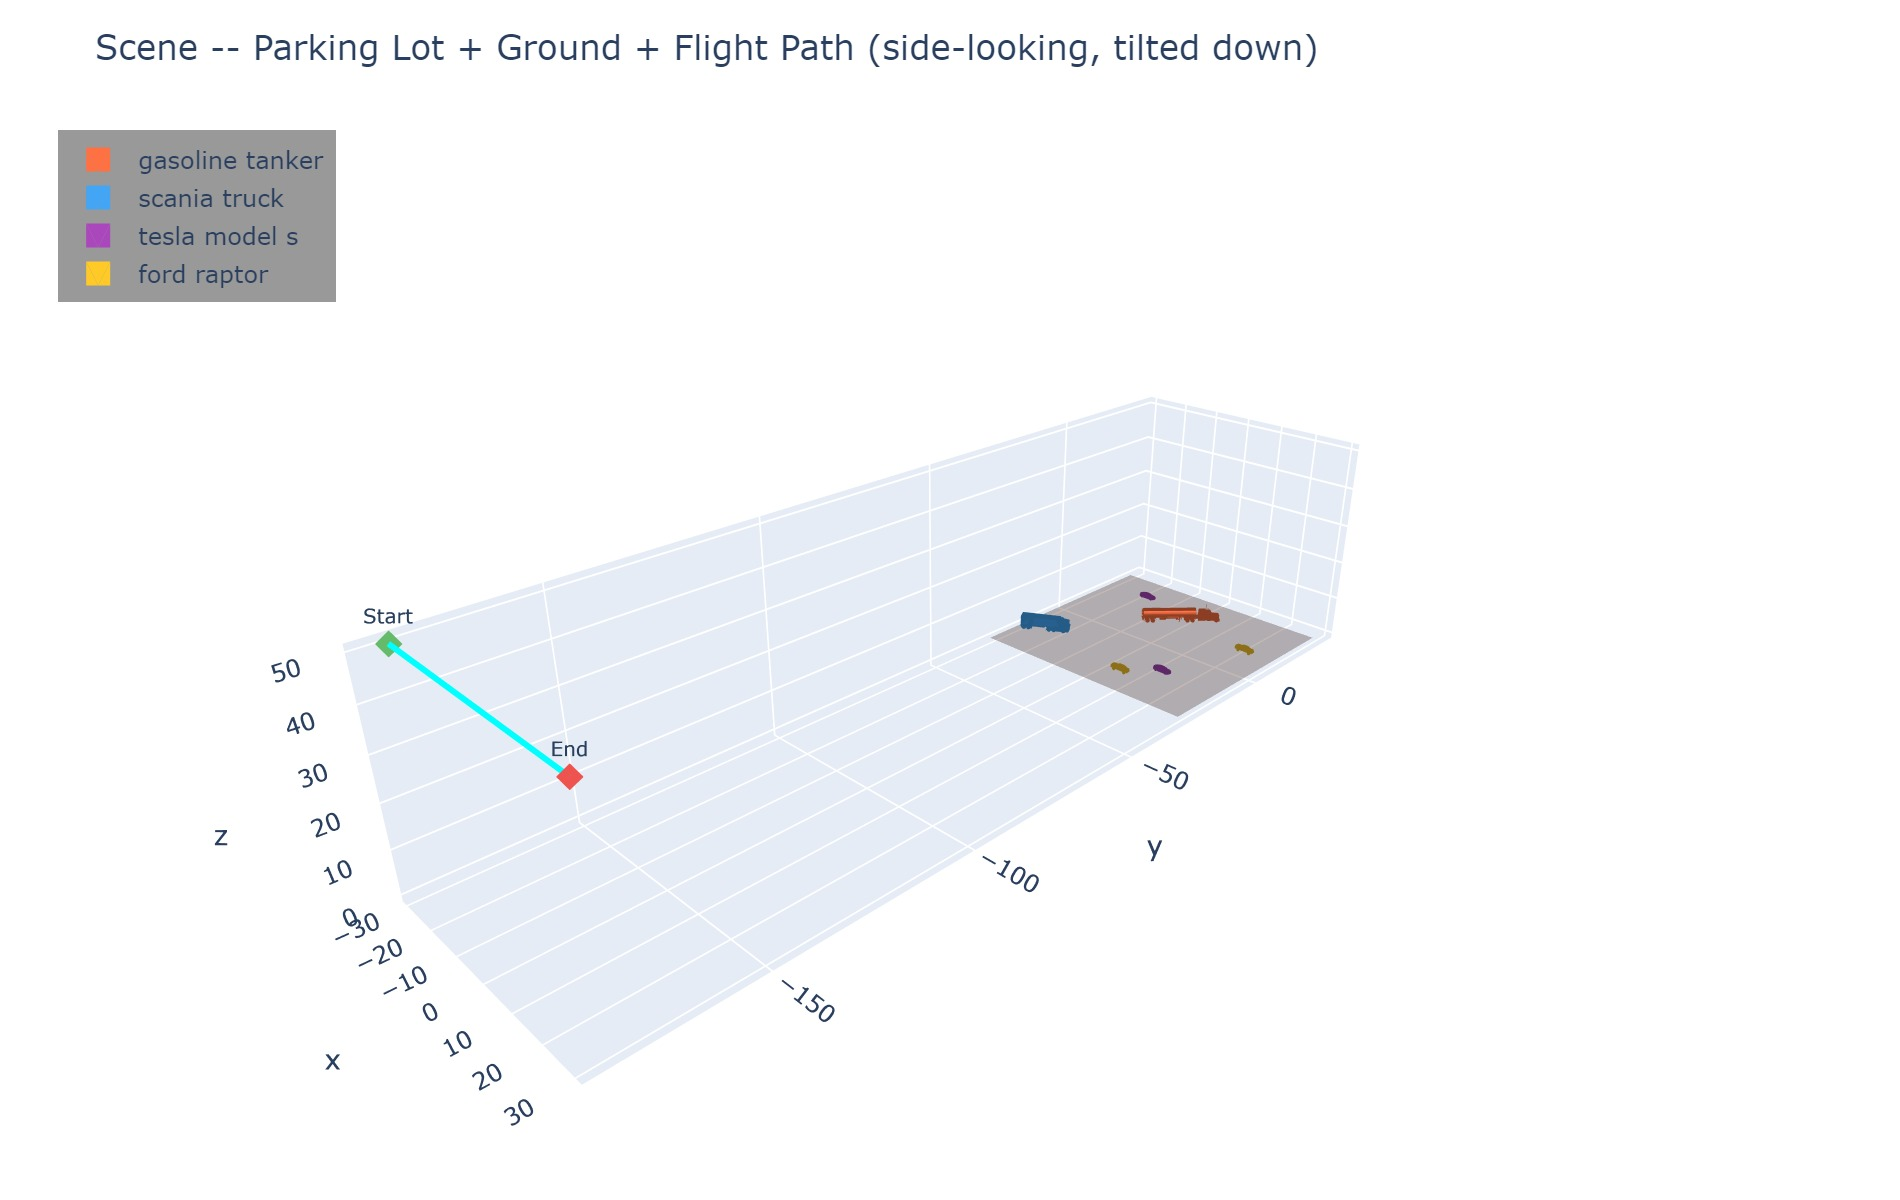

In [12]:
# 3D preview: scene + chained flight path, reusing cached vehicle meshes.
fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=[-30, 30, 30, -30],
        y=[-30, -30, 30, 30],
        z=[0, 0, 0, 0],
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        color="#4E342E",
        opacity=0.35,
        name="Ground plane",
        showscale=False,
        showlegend=False,
    )
)

legend_shown = set()
for v, mesh in zip(vehicles, vehicle_mesh_cache):
    verts_world = mesh["verts"]
    faces_v = mesh["faces"]
    fig.add_trace(
        go.Mesh3d(
            x=verts_world[:, 0],
            y=verts_world[:, 1],
            z=verts_world[:, 2],
            i=faces_v[:, 0],
            j=faces_v[:, 1],
            k=faces_v[:, 2],
            color=VEHICLE_COLORS[v["name"]],
            flatshading=True,
            lighting=dict(ambient=0.55, diffuse=0.6, specular=0.25, roughness=0.6),
            name=v["name"].replace("_", " "),
            showlegend=v["name"] not in legend_shown,
        )
    )
    legend_shown.add(v["name"])

fig.add_trace(
    go.Scatter3d(
        x=platform_x,
        y=np.full_like(platform_x, y_fly),
        z=np.full_like(platform_x, z_fly),
        mode="lines",
        line=dict(color="cyan", width=6),
        name="Flight path",
        showlegend=False,
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[platform_x[0], platform_x[-1]],
        y=[y_fly, y_fly],
        z=[z_fly, z_fly],
        mode="markers+text",
        marker=dict(color=["#66BB6A", "#EF5350"], size=5, symbol="diamond"),
        text=["Start", "End"],
        textposition="top center",
        textfont=dict(size=10),
        name="Flight start/end",
        showlegend=False,
    )
)

fig.update_layout(
    title="Scene -- Parking Lot + Ground + Flight Path (side-looking, tilted down)",
    scene=dict(aspectmode="data", camera=dict(eye=dict(x=1.9, y=-1.9, z=1.3))),
    width=950,
    height=600,
    margin=dict(l=20, r=20, b=20, t=60),
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(0,0,0,0.4)"),
)
show(fig)

## Simulation & SAR Processing

`sim_radar` ray-traces the LFM chirp against the ground plane and all six vehicles **together, in one call** — mixed materials and mesh sizes (13k-415k facets) are handled transparently. Each call is capped at 213 pulses (≈4.0 s), so reaching the full ≈60 m flight means calling it `n_segments` = 3 times, each continuing motion from the last. Ray density is lowered (`density=0.5`) to keep runtime reasonable on these heavier meshes. Thermal noise (`sim_radar`'s `noise` output) is added to each segment.

Two processing stages:
1. **Range Compression (Fast-Time FFT)** — per segment, then concatenated.
2. **Sliding-Window Back-Projection** — each pixel is focused only from pulses within its own real-beam footprint, with a raised-cosine taper:

$$R_n = \sqrt{(x_p-x_n)^2 + (y_p-y_{fly})^2 + (z_{ref}-z_{fly})^2}$$

BPA assumes every pixel sits at `z_ref` — exact for the bare ground, wrong inside vehicle footprints, which is exactly what produces layover.

In [13]:
# -- Range compression setup: identical for every segment, computed once -------------
range_win = scipy.signal.windows.chebwin(pulse_samples, at=50)
NFFT = pulse_samples * 4  # zero-padding -> finer range grid
freq_axis = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1 / fs))
range_axis_full = freq_axis * c * tpd / (2 * bw)
range_window_lo, range_window_hi = R_near - 15, R_far + 15
range_mask = (range_axis_full >= range_window_lo) & (range_axis_full <= range_window_hi)
range_axis = range_axis_full[range_mask]

# Chain sim_radar calls: one per segment, reusing the same radar with a fresh
# set_motion(...) continuing from the previous segment's positions.
t_offset = (num_pulses - 1) / 2 * prp
range_profile_list = []
tic_total = time.time()
for seg_idx, seg_center in enumerate(segment_centers):
    seg_locations = [
        seg_center + (radar.time_prop["timestamp"] - t_offset) * v_platform,
        y_fly,
        z_fly,
    ]
    radar.set_motion(location=seg_locations, rotation=[90, -dep_center, 0])

    tic = time.time()
    # density=0.5 trades ray count for runtime on these heavier meshes.
    data = sim_radar(radar, targets, density=0.5, level="pulse")
    # Add thermal noise for a realistic speckled background.
    baseband_seg = data["baseband"] + data["noise"]
    print(
        f"  segment {seg_idx+1}/{n_segments} (centre x={seg_center:.1f} m): "
        f"sim time {time.time()-tic:.0f} s"
    )

    raw_seg = baseband_seg[0, :, :]
    range_profile_full_seg = np.fft.fftshift(
        np.fft.fft(raw_seg * range_win[np.newaxis, :], NFFT, axis=1), axes=1
    )
    range_profile_list.append(range_profile_full_seg[:, range_mask])

range_profile = np.concatenate(range_profile_list, axis=0)

print(f"All {n_segments} segments complete in {time.time()-tic_total:.0f} s total.")
print(
    f"  Combined range_profile shape: {range_profile.shape}  (num_pulses_total x range_bins)"
)
print(f"  Range axis: {range_axis[0]:.1f} to {range_axis[-1]:.1f} m")
print(f"  Range resolution after compression: {range_res:.3f} m")

  segment 1/3 (centre x=-20.0 m): sim time 89 s
  segment 2/3 (centre x=0.0 m): sim time 89 s
  segment 3/3 (centre x=20.0 m): sim time 83 s
All 3 segments complete in 261 s total.
  Combined range_profile shape: (639, 1668)  (num_pulses_total x range_bins)
  Range axis: 147.9 to 226.0 m
  Range resolution after compression: 0.187 m


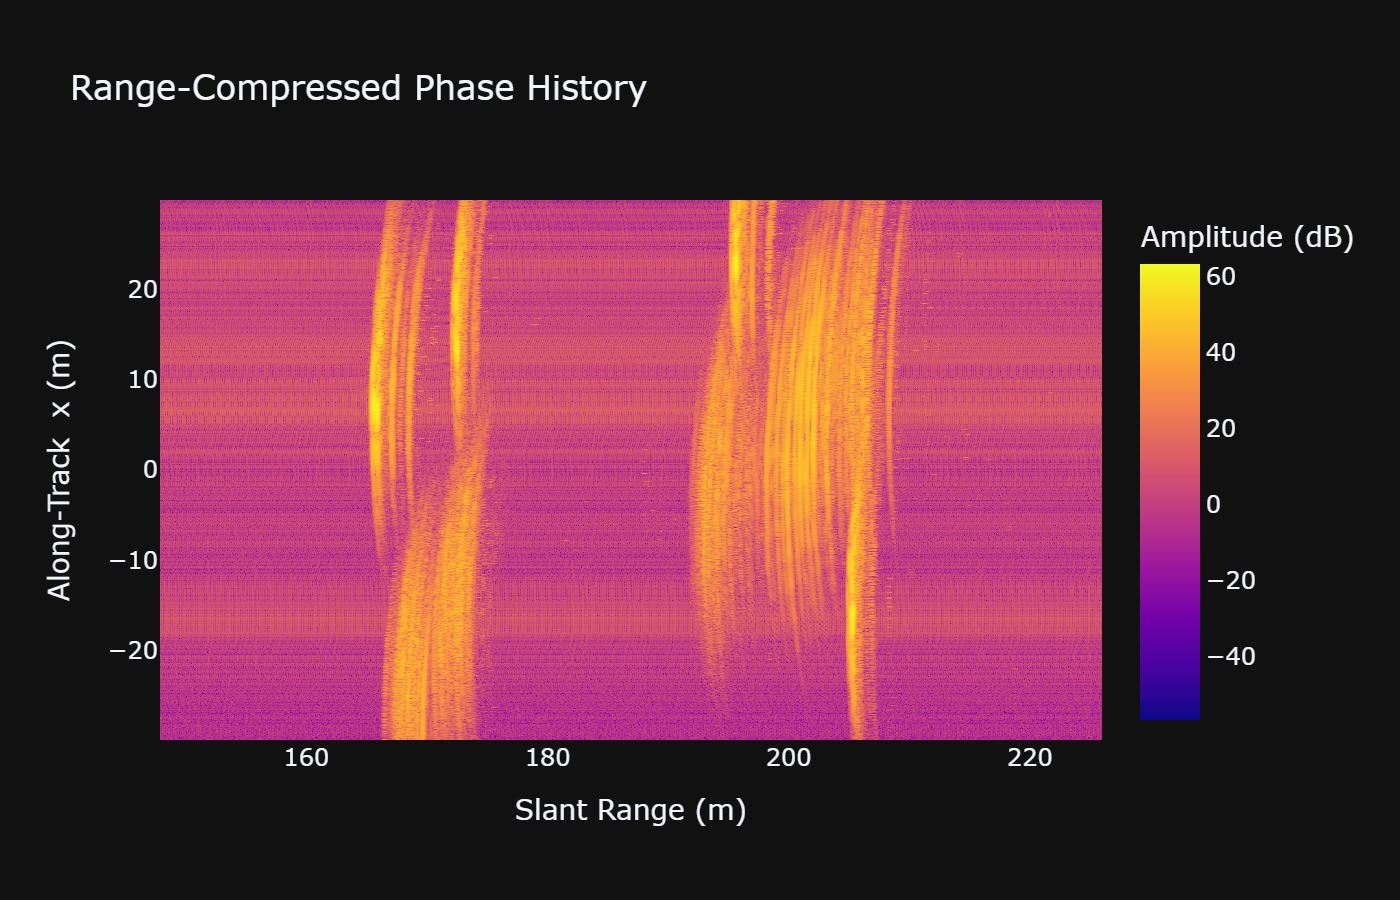

In [14]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=range_axis,
        y=platform_x,
        z=20 * np.log10(np.abs(range_profile) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 2: Sliding-Window Stripmap Focusing

Each pulse at along-track position $x_n$ only contributes to image columns within its real-beam footprint, tapered by a continuous raised-cosine window that rolls smoothly to zero at the footprint edge — controlling sidelobes without a hard cutoff. Unlike a global sum over the whole flight, each pulse touches only a narrow local slice of the image, so achievable swath length no longer depends on pulses-per-call limits.

In [15]:
# -- Image grid ---------------------------------------------------------------
img_ranges = np.arange(y0, y1 + range_res, range_res)

half_footprint = footprint_length / 2
az_window = (
    total_flight_length / 2 + half_footprint
)  # pixels just past the flight ends still get partial dwell
az_step = 0.5  # m -- kept close to az_res_stripmap; finer would be costly without adding real information
img_az = np.arange(cx - az_window, cx + az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az x {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(
    f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_res:.3f} m)"
)

# Sliding-window stripmap BPA: each pulse only contributes to columns within its
# real-beam footprint, weighted by a raised-cosine taper -- not a global sum.
dz_ref = (
    z_fly - z_ref
)  # fixed vertical offset: flat-earth reference vs. flight altitude
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
tic_bpa = time.time()
for pulse_idx in range(num_pulses_total):
    x_n = platform_x[pulse_idx]

    # Image columns within this pulse's real-beam footprint
    lo = np.searchsorted(img_az, x_n - half_footprint, side="left")
    hi = np.searchsorted(img_az, x_n + half_footprint, side="right")
    if hi <= lo:
        continue
    az_local = img_az[lo:hi]

    # Raised-cosine taper vs. normalised distance from x_n
    u = (az_local - x_n) / half_footprint
    w_local = 0.5 * (1.0 + np.cos(np.pi * u))

    dx = az_local - x_n
    dy = img_ranges[:, np.newaxis] - y_fly
    R_n = np.sqrt(dx[np.newaxis, :] ** 2 + dy**2 + dz_ref**2)  # (n_ranges, n_local_az)

    interp_fn = interp1d(
        range_axis,
        range_profile[pulse_idx],
        kind="linear",
        bounds_error=False,
        fill_value=0,
    )
    interp_sig = interp_fn(R_n.ravel()).reshape(R_n.shape)
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)

    sar_image[lo:hi, :] += (w_local[np.newaxis, :] * interp_sig * phase_corr).T
toc_bpa = time.time()

print(f"Back-projection complete in {toc_bpa - tic_bpa:.0f} s.")
print(f"  SAR image shape : {sar_image.shape}  (Naz x Nr)")

Image grid: 159 az x 268 range pixels
  Azimuth : -39.3 to 39.7 m  (step 0.50 m)
  Range   : -25.0 to 25.0 m  (step 0.187 m)
Back-projection complete in 1 s.
  SAR image shape : (159, 268)  (Naz x Nr)


## Results: Focused SAR Image

The bare ground appears dim and speckled (its specular return mostly forward-scatters away at this depression angle), with six vehicle returns of differing brightness: the box truck and tanker (large, favorable double-bounce geometry) stand out; the sedan and pickup (smaller, angle-sensitive glints) are fainter — matching real SAR imagery of vehicle yards. Vehicles are **not** at their true (x, y): BPA's flat reference is exact for the ground but wrong for anything above it, so every vehicle shifts toward the radar (shorter apparent range). Markers below show true position against each shifted return.

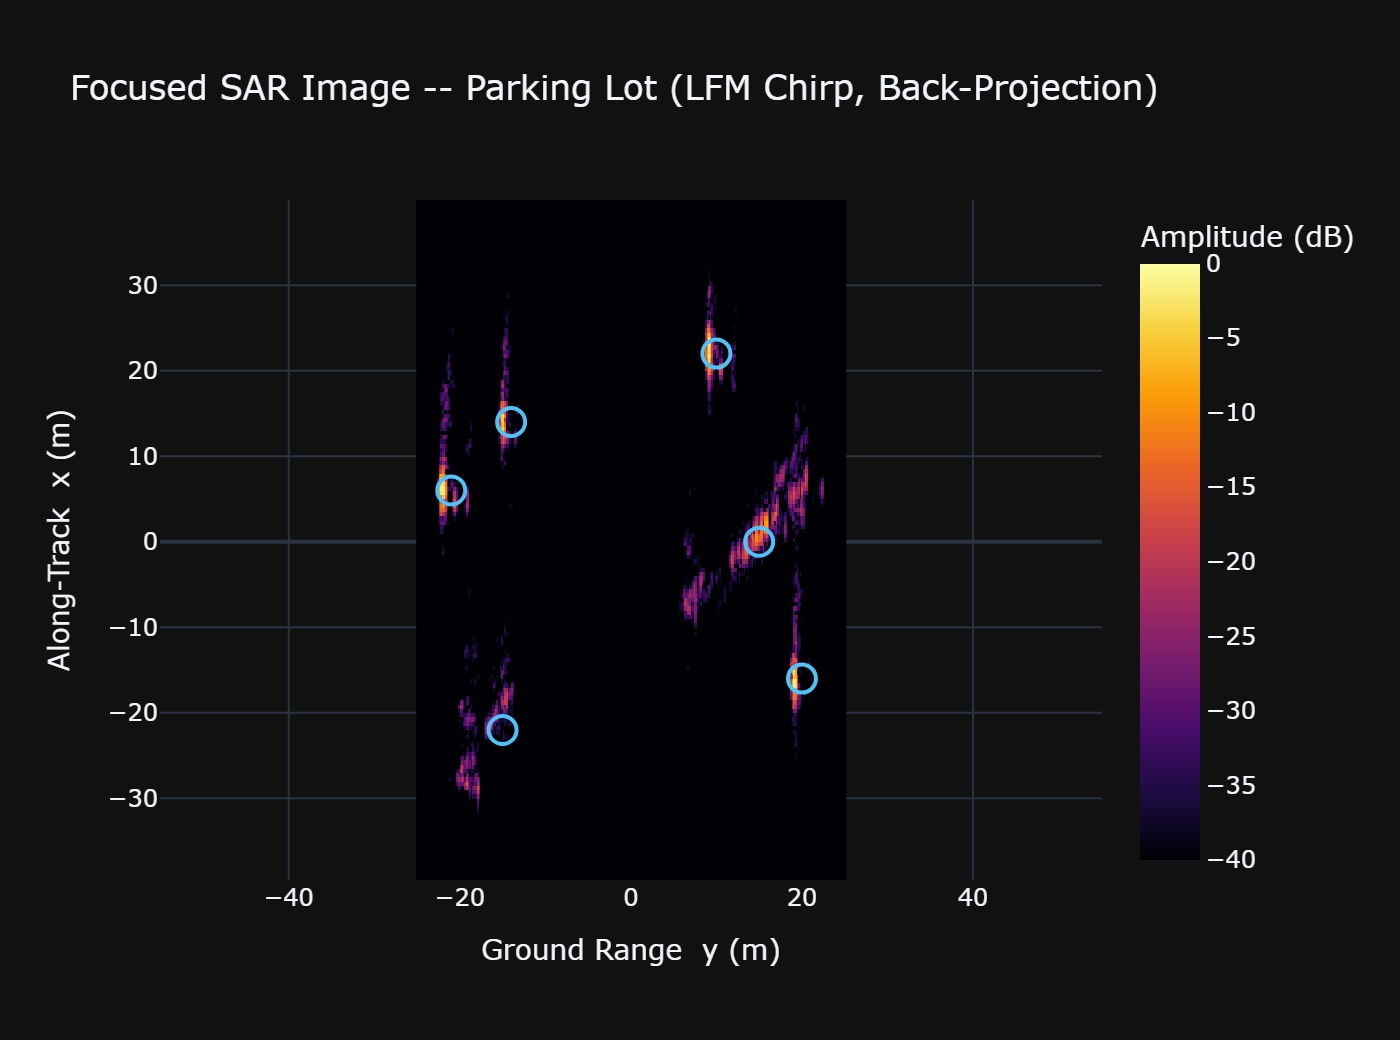

In [16]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()  # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges,
        y=img_az,
        z=sar_amp_db,
        colorscale="Inferno",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-40,
        zmax=0,
    )
)
# True (undisplaced) vehicle positions, for comparison against their layover-shifted
# bright returns above -- the offset between a marker and its nearby bright blob IS
# the layover this notebook is about.
fig.add_trace(
    go.Scatter(
        x=[v["y"] for v in vehicles],
        y=[v["x"] for v in vehicles],
        mode="markers",
        marker=dict(symbol="circle-open", size=14, color="#4FC3F7", line=dict(width=2)),
        name="True vehicle position",
    )
)

fig.update_layout(
    title="Focused SAR Image -- Parking Lot (LFM Chirp, Back-Projection)",
    xaxis_title="Ground Range  y (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=520,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(0,0,0,0.4)"),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
show(fig)

## Summary

A C-band stripmap LFM SAR simulation of a small parking lot — six vehicles (four models) on flat ground:

| Stage | Key Parameters | Result |
|---|---|---|
| Scene | 6 vehicle meshes (13k-415k facets) + 60x60 m ground, PEC by default | Close-in parking-lot scene, tens of meters across |
| Waveform | fc=4 GHz, B=800 MHz, τ=2 μs | ΔR=0.187 m, fs≈1.3 GHz |
| Flight | v=5 m/s, 3x213 pulses, alt=50 m, standoff=180 m | ≈60 m chained flight, ≈14-18° depression |
| Antenna | narrow az (0.75 m, cos^277), wide el (cos³) | beamwidths matched to illumination geometry |
| Simulation | ground + 6 vehicles ray-traced together, density=0.5, noise added | box truck/tanker strong; sedans/pickups fainter |
| Range compression | fast-time FFT, Chebyshev window, per segment | ΔR=0.187 m |
| Image formation | sliding-window stripmap BPA, flat z_ref=0 (exact) | six vehicles, all layover-displaced |
| Validation | bounding-box height vs. predicted image position | tanker's bright return matches predicted layover |

### Relief Displacement (Layover)

BPA focuses perfectly where a target sits at its assumed flat reference elevation — exact here for the ground, but the vehicles rise above it. A vehicle above `z_ref` returns energy at a shorter range than the ground beside it, so BPA places it too close to the radar. This is a real, well-documented SAR artifact; true ortho-rectification needs actual scene height, not a flat reference. Nothing here scripts the layover — it falls out of ray-tracing real 3-D geometry and focusing it with a flat-earth assumption.

### RadarSimPy Capabilities Showcased

- Ray tracing multiple STL meshes together in one scene, mixed materials (PEC vehicles, dielectric ground) with per-target `skip_diffusion`/`environment` flags
- Independently configurable az/el antenna patterns, with the az `cos^n` exponent derived to match the real-aperture beamwidth
- `density`-tunable ray tracing to trade runtime for fidelity on heavy meshes
- Long-duration flight synthesis by chaining `sim_radar` calls, each with its own `set_motion(...)`
- Realistic thermal noise via `sim_radar`'s `noise` output
- Angle-sensitive backscatter from real geometry — dimmer vehicles are a physically ray-traced feature, not a bug

### Things to Try

| Experiment | How | Effect |
|---|---|---|
| Remove layover | Use `scene_height()` per-pixel instead of constant `z_ref` | Ortho-rectified image |
| Add vehicles | Extend `vehicles` with more models from `models/vehicles/*.stl` | More targets to compare |
| Re-tune a weak yaw | Sweep `rotation` for sedan/pickup | Find angles where return registers |
| Steeper depression | Reduce standoff (`y0 - y_fly`) | Double-bounce falloff past ~25° |
| Higher resolution | Increase `bw` or shrink `Da` | Finer ΔR/Δaz, higher fs/runtime cost |
| More looks | Increase `prf_margin` | Smoother speckle, same Dₐ/2 resolution floor |